# Task 1: Filtering Non-Australian Documents — part_0.parquet Experiment

## Objective
On top of the FineWeb Australian subset (50B tokens), further remove documents that clearly do not originate from Australia.
This notebook validates the methodology on `part_0.parquet`. The pipeline can later be applied on the full dataset.

## Design Principles
Design requirements:
- ✅ **Strong features**: a single signal is unambiguous
- ❌ **No fuzzy rules**: spelling differences, mentions of foreign content → high false-positive risk on news/academic texts

Accordingly, a **"hard rules + Australian protection"** two-stage design is used, aiming for high Precision while accepting lower Recall.

## Rule Selection
Four categories of strong signals were retained after discussion:

| Rule | Strength | Notes |
|---|---|---|
| Postcode (US/UK/CA) | ⭐⭐⭐ | Strongest, format is unambiguous |
| Date format (MM/DD where DD>12) | ⭐⭐⭐ | Requires counter-evidence check (if DD/MM exists, revoke) |
| Phone area code (+1/+44) | ⭐⭐ | Requires canonical format + no +61 |
| Source URL foreign TLD | ⭐⭐⭐⭐ | Metadata-level signal, most reliable |

**Explicitly rejected** rules:
- ❌ Institutional keywords (Medicare, IRS): Australia also uses these, or they are cross-referenced frequently
- ❌ Imperial units: Australians mix imperial in colloquial speech; aviation/cooking contexts retain imperial
- ❌ Spelling differences (color vs colour): too much risk of false positives

## Australian Protection Mechanism
Whenever a hard rule fires, check if the document has ≥ 2 strong Australian signals (domain / phone / state postcode / local institutions). If so, revoke the deletion.

---
## 1. Environment and Dependencies

In [1]:
!pip install cudf-cu12 cupy-cuda12x numba-cuda -q

# Core dependencies
import cudf
import cupy as cp
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

print(f"cuDF version: {cudf.__version__}")
print(f"CuPy version: {cp.__version__}")
print(f"GPU available: {cp.cuda.runtime.getDeviceCount()} device(s)")


cuDF version: 26.04.000
CuPy version: 14.0.1
GPU available: 1 device(s)


---
## 2. Configuration

- `DATA_PATH`: path to `part_0.parquet`
- `SAMPLE_N`: use a small sample for debugging (set to None for full run)
- `RANDOM_SEED`: reproducible sampling

In [2]:
DATA_PATH = "/home/jovyan/data/AUTokens50/part_0.parquet"   # same dir as notebook
SAMPLE_N = None                      # set to 100_000 for debugging, None for full run
RANDOM_SEED = 42

# Key thresholds (tunable)
POSTCODE_MIN_HITS = 2                # document needs >=2 postcode hits to trigger
PHONE_MIN_HITS = 2                   # same
US_DATE_MIN_HITS = 3                 # need at least 3 MM/DD dates to count as a pattern
AU_PROTECT_THRESHOLD = 2             # need >=2 AU signals to trigger protection


---
## 3. Data Loading & Schema Exploration

FineWeb-derived data typically contains `text`, `url`, `date`, `language` fields. Let's check the actual schema.

In [3]:
# Load parquet directly with cuDF (GPU-accelerated)
df = cudf.read_parquet(DATA_PATH)

if SAMPLE_N is not None:
    df = df.sample(n=min(SAMPLE_N, len(df)), random_state=RANDOM_SEED).reset_index(drop=True)

print(f"Number of documents: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
df.head(3)


Number of documents: 278,106
Columns: ['text', 'id', 'dump', 'url', 'date', 'file_path', 'language', 'language_score', 'token_count']
Memory usage: 3.19 GB


,text,id,dump,url,date,file_path,language,language_score,token_count
664,"Justine Davies –, Monday, January, 31, 2011, (...",<urn:uuid:0f3c1f06-4af1-4da0-96f9-91a7473f205f>,CC-MAIN-2013-20,http://blogs.news.com.au/moneystuff/index.php/...,2013-05-18T06:19:58Z,s3://commoncrawl/crawl-data/CC-MAIN-2013-20/se...,en,0.961377,1484
5457,Interview: Jenny Macpherson\n- by Rowena Scott...,<urn:uuid:12bb0bca-ddf8-4522-97ee-5583b8c93b93>,CC-MAIN-2013-20,http://www.bicycles.net.au/2010/10/interview-j...,2013-05-18T06:53:36Z,s3://commoncrawl/crawl-data/CC-MAIN-2013-20/se...,en,0.967261,2409
5459,The foundations for successful riding\n19 post...,<urn:uuid:74766fcf-d5eb-44fd-b925-01bd98098d70>,CC-MAIN-2013-20,http://www.bicycles.net.au/forums/viewtopic.ph...,2013-05-18T06:29:13Z,s3://commoncrawl/crawl-data/CC-MAIN-2013-20/se...,en,0.975258,2439


In [4]:
# Check key columns
HAS_URL = "url" in df.columns
HAS_TEXT = "text" in df.columns

assert HAS_TEXT, "text column is required"
print(f"✅ text column present")
print(f"{'✅' if HAS_URL else '⚠️ '} url column {'present' if HAS_URL else 'missing — TLD rule will be skipped'}")

# Text length distribution
text_lens = df["text"].str.len()
print(f"\nText length statistics:")
print(f"  Median:  {text_lens.median():.0f} chars")
print(f"  Mean:    {text_lens.mean():.0f} chars")
print(f"  Max:     {text_lens.max():,} chars")
print(f"  Empty:   {(text_lens == 0).sum()}")


✅ text column present
✅ url column present

Text length statistics:
  Median:  6663 chars
  Mean:    11074 chars
  Max:     583,887 chars
  Empty:   0


In [5]:
# If url column exists, inspect TOP 20 domains (quick data sanity check)
if HAS_URL:
    domains = df["url"].str.extract(r'https?://([^/]+)', expand=False)
    top_domains = domains.value_counts().head(20).to_pandas()
    print("TOP 20 domains:")
    print(top_domains)


TOP 20 domains:
url
www.abc.net.au              29527
www.theage.com.au           28497
www.smh.com.au              27052
www.watoday.com.au           5555
www.canberratimes.com.au     4540
www.news.com.au              4489
adb.anu.edu.au               3397
www.theroar.com.au           3164
www.bicycles.net.au          3081
www.brisbanetimes.com.au     2900
www.foxsports.com.au         2435
trove.nla.gov.au             2349
www.thepunch.com.au          2275
www.essentialbaby.com.au     2257
mobile.abc.net.au            2234
www.crikey.com.au            2134
www.adelaidenow.com.au       2022
parlinfo.aph.gov.au          1918
www.bubhub.com.au            1902
www.abs.gov.au               1793
Name: count, dtype: int64


---
## 4. Rule Definitions

### 4.1 Postcode Rules

**US postcodes**: must be paired with a state code (e.g., `CA 90210`). Looking at 5-digit numbers alone would cause false positives.

**UK postcodes**: format is distinctive (e.g., `SW1A 1AA`), low false-positive rate.

**Canadian postcodes**: alternating letter-digit pattern (e.g., `K1A 0B1`), unique format.

⚠️ Note: cuDF's regex engine **does not support lookahead/lookbehind**. All patterns use standard syntax.

In [6]:
# US: 50 state codes + DC + 5-digit ZIP (with optional +4 extension)
US_STATE_CODES = ("AL|AK|AZ|AR|CA|CO|CT|DE|FL|GA|HI|ID|IL|IN|IA|KS|KY|LA|"
                  "ME|MD|MA|MI|MN|MS|MO|MT|NE|NV|NH|NJ|NM|NY|NC|ND|"
                  "OH|OK|OR|PA|RI|SC|SD|TN|TX|UT|VT|VA|WA|WV|WI|WY|DC")
US_ZIP_PATTERN = rf"\b(?:{US_STATE_CODES})\s+\d{{5}}(?:-\d{{4}})?\b"

# UK postcode (simplified stable version)
UK_POSTCODE_PATTERN = r"\b[A-Z]{1,2}[0-9][A-Z0-9]?\s?[0-9][A-Z]{2}\b"

# Canadian postcode (must have space separator)
CA_POSTCODE_PATTERN = r"\b[A-CEGHJ-NPR-TVXY][0-9][A-CEGHJ-NPR-TV-Z]\s[0-9][A-CEGHJ-NPR-TV-Z][0-9]\b"

print("US_ZIP:", US_ZIP_PATTERN[:80], "...")
print("UK_POSTCODE:", UK_POSTCODE_PATTERN)
print("CA_POSTCODE:", CA_POSTCODE_PATTERN)


US_ZIP: \b(?:AL|AK|AZ|AR|CA|CO|CT|DE|FL|GA|HI|ID|IL|IN|IA|KS|KY|LA|ME|MD|MA|MI|MN|MS|MO| ...
UK_POSTCODE: \b[A-Z]{1,2}[0-9][A-Z0-9]?\s?[0-9][A-Z]{2}\b
CA_POSTCODE: \b[A-CEGHJ-NPR-TVXY][0-9][A-CEGHJ-NPR-TV-Z]\s[0-9][A-CEGHJ-NPR-TV-Z][0-9]\b


### 4.2 Date Format Rule

Core logic:
- Seeing `\d{1,2}/13-31/\d{4}` → second number > 12, can only be `MM/DD/YYYY` (US format)
- Seeing `13-31/\d{1,2}/\d{4}` → first number > 12, can only be `DD/MM/YYYY` (AU/UK format, **counter-evidence**)

Strategy: only trigger when **US format hits many times AND no counter-evidence**.

In [7]:
# US format signal: second segment (day) is 13-31
US_DATE_PATTERN = r"\b\d{1,2}/(?:1[3-9]|2[0-9]|3[01])/\d{4}\b"

# AU/UK format counter-evidence: first segment (day) is 13-31
AU_DATE_PATTERN = r"\b(?:1[3-9]|2[0-9]|3[01])/\d{1,2}/\d{4}\b"

print("US_DATE (MM/DD, DD>12):", US_DATE_PATTERN)
print("AU_DATE (DD/MM, DD>12):", AU_DATE_PATTERN)


US_DATE (MM/DD, DD>12): \b\d{1,2}/(?:1[3-9]|2[0-9]|3[01])/\d{4}\b
AU_DATE (DD/MM, DD>12): \b(?:1[3-9]|2[0-9]|3[01])/\d{1,2}/\d{4}\b


### 4.3 Phone Area Code Rule

Must be in **canonical format** (with +, parentheses, or standard separators). Bare 10-digit numbers don't count — they would false-positive on order IDs etc.

- US/Canada: `+1-xxx-xxx-xxxx` or `(xxx) xxx-xxxx` or `1-800-xxx-xxxx`
- UK: `+44 xxx xxx xxxx`
- AU counter-evidence: `+61 x xxxx xxxx`

In [8]:
# US/CA phone: requires +1 prefix, parenthesized area code, or 1-800 format
US_PHONE_PATTERN = r"(?:\+1[\s\-\.]\d{3}[\s\-\.]\d{3}[\s\-\.]\d{4}|\(\d{3}\)\s?\d{3}[\s\-\.]?\d{4}|1[\s\-]?8(?:00|33|44|55|66|77|88)[\s\-]?\d{3}[\s\-]?\d{4})"

# UK phone: starts with +44
UK_PHONE_PATTERN = r"\+44[\s\-]?\(?0?\)?\s?\d{2,4}[\s\-]?\d{3,4}[\s\-]?\d{3,4}"

# AU phone counter-evidence
AU_PHONE_PATTERN = r"\+61[\s\-]?\(?\d\)?[\s\-]?\d{4}[\s\-]?\d{4}"

print("US_PHONE:", US_PHONE_PATTERN)
print("UK_PHONE:", UK_PHONE_PATTERN)
print("AU_PHONE:", AU_PHONE_PATTERN)


US_PHONE: (?:\+1[\s\-\.]\d{3}[\s\-\.]\d{3}[\s\-\.]\d{4}|\(\d{3}\)\s?\d{3}[\s\-\.]?\d{4}|1[\s\-]?8(?:00|33|44|55|66|77|88)[\s\-]?\d{3}[\s\-]?\d{4})
UK_PHONE: \+44[\s\-]?\(?0?\)?\s?\d{2,4}[\s\-]?\d{3,4}[\s\-]?\d{3,4}
AU_PHONE: \+61[\s\-]?\(?\d\)?[\s\-]?\d{4}[\s\-]?\d{4}


### 4.4 Source URL TLD Rule (if url column exists)

This is the **strongest signal**: the TLD of the document's source URL largely determines its origin.
- `.gov.uk` / `.co.uk` → UK
- `.gc.ca` / `.ca` → Canada
- `.govt.nz` / `.co.nz` → New Zealand (also non-AU, remove)
- `.gov` / `.mil` → US (US-exclusive)
- `.edu` → US educational institution

⚠️ If `.au` is present it triggers protection regardless of other signals.

In [9]:
NON_AU_TLD_PATTERN = r"\.(gov\.uk|co\.uk|org\.uk|ac\.uk|nhs\.uk|gc\.ca|govt\.nz|co\.nz|org\.nz|ac\.nz|gov|mil|edu)(/|$|\s)"
AU_TLD_PATTERN = r"\.(com|net|org|gov|edu|id|asn)\.au(/|$|\s|\W)"

print("NON_AU_TLD:", NON_AU_TLD_PATTERN)
print("AU_TLD:", AU_TLD_PATTERN)


NON_AU_TLD: \.(gov\.uk|co\.uk|org\.uk|ac\.uk|nhs\.uk|gc\.ca|govt\.nz|co\.nz|org\.nz|ac\.nz|gov|mil|edu)(/|$|\s)
AU_TLD: \.(com|net|org|gov|edu|id|asn)\.au(/|$|\s|\W)


### 4.5 Australian Protection Signals

Once a hard rule fires, count how many of these Australian positive signals appear. Protection threshold: ≥ 2 categories.

In [10]:
# Australian strong signal patterns (each counted separately, summed afterwards)
AU_SIGNALS = {
    "au_tld":     AU_TLD_PATTERN,
    "au_phone":   AU_PHONE_PATTERN,
    "au_state":   r"\b(?:NSW|VIC|QLD|WA|SA|TAS|ACT|NT)\s+\d{4}\b",
    "au_cities":  r"\b(?:Sydney|Melbourne|Brisbane|Perth|Adelaide|Canberra|Hobart|Darwin|Wollongong|Newcastle|Geelong|Townsville)\b",
    "au_govs":    r"\b(?:Centrelink|ATO|NDIS|ATAR|HSC|VCE|TAFE|AusPost|Services Australia|Medibank)\b",
    "au_brands":  r"\b(?:Woolworths|Coles|Bunnings|Telstra|Optus|Qantas|Jetstar|Westpac|Commonwealth Bank|NAB)\b",
    "au_sports":  r"\b(?:AFL|NRL|A-League|Wallabies|Socceroos|Matildas|Big Bash)\b",
    "au_currency": r"\b(?:AUD|A\$)\b",
}

for name, pat in AU_SIGNALS.items():
    print(f"  {name}: {pat[:80]}")


  au_tld: \.(com|net|org|gov|edu|id|asn)\.au(/|$|\s|\W)
  au_phone: \+61[\s\-]?\(?\d\)?[\s\-]?\d{4}[\s\-]?\d{4}
  au_state: \b(?:NSW|VIC|QLD|WA|SA|TAS|ACT|NT)\s+\d{4}\b
  au_cities: \b(?:Sydney|Melbourne|Brisbane|Perth|Adelaide|Canberra|Hobart|Darwin|Wollongong|
  au_govs: \b(?:Centrelink|ATO|NDIS|ATAR|HSC|VCE|TAFE|AusPost|Services Australia|Medibank)\
  au_brands: \b(?:Woolworths|Coles|Bunnings|Telstra|Optus|Qantas|Jetstar|Westpac|Commonwealth
  au_sports: \b(?:AFL|NRL|A-League|Wallabies|Socceroos|Matildas|Big Bash)\b
  au_currency: \b(?:AUD|A\$)\b


---
## 5. Apply Rules — GPU Batch Processing

Use `cudf.Series.str.count()` for batch counting. This is the **bottleneck** of the pipeline, but cuDF runs 50-100x faster than pandas on GPU.

In [11]:
%%time
# Fill null text
text = df["text"].fillna("")

# ===== Hard rule hit counts =====
df["hit_us_zip"]       = text.str.count(US_ZIP_PATTERN)
df["hit_uk_postcode"]  = text.str.count(UK_POSTCODE_PATTERN)
df["hit_ca_postcode"]  = text.str.count(CA_POSTCODE_PATTERN)
df["hit_us_date"]      = text.str.count(US_DATE_PATTERN)
df["hit_au_date"]      = text.str.count(AU_DATE_PATTERN)       # counter-evidence
df["hit_us_phone"]     = text.str.count(US_PHONE_PATTERN)
df["hit_uk_phone"]     = text.str.count(UK_PHONE_PATTERN)
df["hit_au_phone"]     = text.str.count(AU_PHONE_PATTERN)      # counter-evidence

print("Hard rule counting complete")


Hard rule counting complete
CPU times: user 10min 13s, sys: 710 ms, total: 10min 13s
Wall time: 10min 14s


In [12]:
%%time
# ===== Australian signal counts =====
au_signal_cols = []
for name, pat in AU_SIGNALS.items():
    col = f"au_{name}"
    df[col] = text.str.count(pat).astype("int32").clip(upper=1)   # each category counts 0/1
    au_signal_cols.append(col)

df["au_signal_count"] = sum(df[c] for c in au_signal_cols)
print("Australian signal counting complete")
print(f"Australian signal distribution:")
print(df["au_signal_count"].value_counts().sort_index().to_pandas())


Australian signal counting complete
Australian signal distribution:
au_signal_count
0    109701
1    123419
2     38833
3      5471
4       601
5        74
6         7
Name: count, dtype: int64
CPU times: user 1min 59s, sys: 177 ms, total: 2min
Wall time: 2min


In [13]:
%%time
# ===== Source URL TLD check =====
if HAS_URL:
    url = df["url"].fillna("")
    df["url_non_au"] = url.str.contains(NON_AU_TLD_PATTERN, regex=True)
    df["url_is_au"]  = url.str.contains(AU_TLD_PATTERN, regex=True)
    
    print(f"Documents with non-AU TLD URL: {df['url_non_au'].sum():,}")
    print(f"Documents with .au URL:        {df['url_is_au'].sum():,}")
else:
    df["url_non_au"] = False
    df["url_is_au"]  = False
    print("⚠️  No url column, skipping TLD rule")


Documents with non-AU TLD URL: 5
Documents with .au URL:        277,926
CPU times: user 19.2 ms, sys: 7 ms, total: 26.2 ms
Wall time: 22.8 ms


---
## 6. Final Decision Logic

For each document, in order:

1. **Strongest hard signal**: source URL has non-AU TLD AND source URL does not contain `.au` → Delete
2. **Secondary hard signals**: any postcode / date / phone rule hits above threshold → Candidate for deletion
   - BUT if ≥ 2 Australian signals are present → **Protect, revoke deletion**
   - OR source URL contains `.au` → **Protect, revoke deletion**
3. Otherwise keep

Every decision preserves a `reason` field for audit.

In [14]:
# Candidate deletion flags
candidate_flags = {
    "us_zip":       df["hit_us_zip"] >= POSTCODE_MIN_HITS,
    "uk_postcode":  df["hit_uk_postcode"] >= POSTCODE_MIN_HITS,
    "ca_postcode":  df["hit_ca_postcode"] >= POSTCODE_MIN_HITS,
    "us_date":      (df["hit_us_date"] >= US_DATE_MIN_HITS) & (df["hit_au_date"] == 0),
    "us_phone":     (df["hit_us_phone"] >= PHONE_MIN_HITS) & (df["hit_au_phone"] == 0),
    "uk_phone":     (df["hit_uk_phone"] >= PHONE_MIN_HITS) & (df["hit_au_phone"] == 0),
}

for name, mask in candidate_flags.items():
    df[f"flag_{name}"] = mask
    print(f"  Candidate hits {name:12s}: {mask.sum():>10,}")


  Candidate hits us_zip      :         28
  Candidate hits uk_postcode :         73
  Candidate hits ca_postcode :          0
  Candidate hits us_date     :         12
  Candidate hits us_phone    :         56
  Candidate hits uk_phone    :          7


In [15]:
# Aggregate: any hard rule candidate fired
any_hard_flag = sum(candidate_flags.values()) > 0
df["any_hard_flag"] = any_hard_flag

# URL-level strong delete (bypasses protection)
df["strong_delete"] = df["url_non_au"] & (~df["url_is_au"])

# Australian protection
df["au_protected"] = (df["au_signal_count"] >= AU_PROTECT_THRESHOLD) | df["url_is_au"]

# Final decision
df["should_remove"] = df["strong_delete"] | (df["any_hard_flag"] & ~df["au_protected"])

# Statistics
total = len(df)
n_remove = int(df["should_remove"].sum())
n_strong = int(df["strong_delete"].sum())
n_hard_hit = int(df["any_hard_flag"].sum())
n_protected = int((df["any_hard_flag"] & df["au_protected"]).sum())

print(f"Total documents:                   {total:>10,}")
print(f"URL strong delete:                 {n_strong:>10,}  ({n_strong/total:.2%})")
print(f"Hard rule candidate hits:          {n_hard_hit:>10,}  ({n_hard_hit/total:.2%})")
print(f"  └─ of which revoked by AU:       {n_protected:>10,}  ({n_protected/total:.2%})")
print(f"─" * 55)
print(f"Final delete:                      {n_remove:>10,}  ({n_remove/total:.2%})")
print(f"Final keep:                        {total - n_remove:>10,}  ({(total-n_remove)/total:.2%})")


Total documents:                      278,106
URL strong delete:                          0  (0.00%)
Hard rule candidate hits:                 167  (0.06%)
  └─ of which revoked by AU:              167  (0.06%)
───────────────────────────────────────────────────────
Final delete:                               0  (0.00%)
Final keep:                           278,106  (100.00%)


In [16]:
# Per-rule deletion contribution (non-exclusive)
print("Deletion contribution by rule (non-exclusive):\n")
remove_mask = df["should_remove"]
for name in candidate_flags:
    col = f"flag_{name}"
    hit_and_remove = int((df[col] & remove_mask).sum())
    print(f"  {name:15s}: {hit_and_remove:>8,} deleted ({hit_and_remove/max(n_remove,1):.1%} of total deleted)")

print(f"  {'url_strong':15s}: {n_strong:>8,} deleted ({n_strong/max(n_remove,1):.1%} of total deleted)")


Deletion contribution by rule (non-exclusive):

  us_zip         :        0 deleted (0.0% of total deleted)
  uk_postcode    :        0 deleted (0.0% of total deleted)
  ca_postcode    :        0 deleted (0.0% of total deleted)
  us_date        :        0 deleted (0.0% of total deleted)
  us_phone       :        0 deleted (0.0% of total deleted)
  uk_phone       :        0 deleted (0.0% of total deleted)
  url_strong     :        0 deleted (0.0% of total deleted)


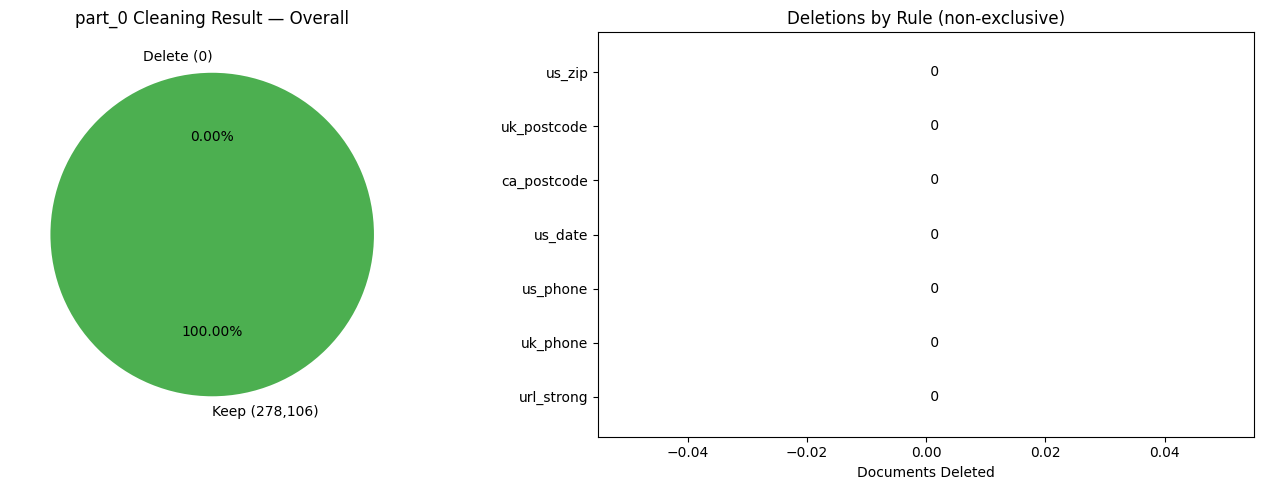

In [17]:
# Visualization: keep/delete + per-rule contribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    [total - n_remove, n_remove],
    labels=[f"Keep ({total-n_remove:,})", f"Delete ({n_remove:,})"],
    autopct="%1.2f%%",
    colors=["#4CAF50", "#F44336"],
    startangle=90,
)
axes[0].set_title("part_0 Cleaning Result — Overall")

rule_names = list(candidate_flags.keys()) + ["url_strong"]
rule_counts = [int((df[f"flag_{n}"] & remove_mask).sum()) for n in candidate_flags] + [n_strong]
axes[1].barh(rule_names, rule_counts, color="#FF7043")
axes[1].set_xlabel("Documents Deleted")
axes[1].set_title("Deletions by Rule (non-exclusive)")
axes[1].invert_yaxis()
for i, v in enumerate(rule_counts):
    axes[1].text(v, i, f" {v:,}", va="center")

plt.tight_layout()
plt.show()


---
## 7. Manual Sampling Checks (Critical)

This is the core step for Precision validation. Three types of samples are inspected:

1. **Deleted documents** (sampled by rule) → verify these really are non-Australian
2. **AU-protected documents** → verify the protection mechanism is reasonable
3. **Randomly kept samples** → look for missed cases (Recall reference)

In [18]:
# Convert to pandas for convenient slicing (small sample only)
def show_samples(mask, label, n=5, cols=None):
    idx = df[mask].index.to_pandas()
    if len(idx) == 0:
        print(f"[{label}] no samples")
        return
    sample_idx = np.random.default_rng(RANDOM_SEED).choice(idx, size=min(n, len(idx)), replace=False)
    sample = df.loc[sample_idx].to_pandas()
    print(f"\n{'='*80}\n[{label}] total {mask.sum():,} docs, random sample of {len(sample_idx)}:\n{'='*80}")
    for i, row in sample.iterrows():
        print(f"\n--- Doc #{i} ---")
        if HAS_URL:
            print(f"URL: {row.get('url', 'N/A')}")
        print(f"AU signals: {row.get('au_signal_count', 0)}")
        hit_info = {k: int(row[f'hit_{k}']) for k in ['us_zip','uk_postcode','ca_postcode','us_date','au_date','us_phone','uk_phone','au_phone']}
        print(f"Hits: {hit_info}")
        text_preview = str(row['text'])[:800]
        print(f"First 800 chars:\n{text_preview}")
        print("-" * 80)


In [19]:
# 7.1 Sample deleted documents by rule
print("\n\n[Check 1] Sample deleted documents by rule — verify Precision\n")

show_samples(df["flag_us_zip"] & df["should_remove"], "US_ZIP hit and deleted", n=3)
show_samples(df["flag_uk_postcode"] & df["should_remove"], "UK_POSTCODE hit and deleted", n=3)
show_samples(df["flag_us_date"] & df["should_remove"], "US_DATE hit and deleted", n=3)
show_samples(df["strong_delete"], "URL strong-deleted", n=3)




[Check 1] Sample deleted documents by rule — verify Precision

[US_ZIP hit and deleted] no samples
[UK_POSTCODE hit and deleted] no samples
[US_DATE hit and deleted] no samples
[URL strong-deleted] no samples


In [20]:
# 7.2 Docs whose deletion was revoked by AU protection
print("\n\n[Check 2] AU-protected documents — verify protection mechanism\n")

protected = df["any_hard_flag"] & df["au_protected"] & ~df["strong_delete"]
show_samples(protected, "Hard rule hit but kept by AU protection", n=5)




[Check 2] AU-protected documents — verify protection mechanism


[Hard rule hit but kept by AU protection] total 167 docs, random sample of 5:

--- Doc #436381 ---
URL: http://www.smh.com.au/business/fairfax-shares-jump-on-trade-me-sale-20121216-2bhie.html?skin=text-only
AU signals: 1
Hits: {'us_zip': 0, 'uk_postcode': 0, 'ca_postcode': 0, 'us_date': 0, 'au_date': 0, 'us_phone': 0, 'uk_phone': 0, 'au_phone': 0}
First 800 chars:
Date: December 17 2012
Fairfax Media is selling its remaining stake in New Zealand online auction house Trade Me in a move that will eliminate most of the company’s debt.
Investment bank UBS has been appointed to sell the 51 per cent stake in Trade Me to institutional investors at about $3.05 a share.
The deal will yield $616 million for Fairfax - publisher of this website - which paid $NZ700 million for the entire business in 2006.
Fairfax shares rose as much 6 per cent in early trade and were recently trading at 52.5 cents, up 1.5 cents or 3 per cent.
Fairfa

In [21]:
# 7.3 Random sample of kept documents
print("\n\n[Check 3] Random sample of kept documents — verify Recall\n")

show_samples(~df["should_remove"], "Kept docs (random)", n=5)




[Check 3] Random sample of kept documents — verify Recall


[Kept docs (random)] total 278,106 docs, random sample of 5:

--- Doc #168651 ---
URL: http://www.dailyreckoning.com.au/australia-forgets-the-little-people/2012/01/04/
AU signals: 1
Hits: {'us_zip': 0, 'uk_postcode': 0, 'ca_postcode': 0, 'us_date': 0, 'au_date': 0, 'us_phone': 0, 'uk_phone': 0, 'au_phone': 0}
First 800 chars:
How about that? Contrary to our gloomy disposition yesterday, the stock market has taken off like a rocket this morning. The material sector is up 2.9% today alone. It was the worst performing sector in Australia on the ASX in 2011, down 25% thanks to lower commodity prices.
Yet this morning copper is up 3%, gold is up 2.5%, and oil prices were up over 4%. We'll get back to oil (and Iran) in a moment. Commodity prices, though, are reacting to the strongest US manufacturing activity in six months. That, plus a survey indicating an expansion in Chinese manufacturing, has investors throwing caution to the 

### 7.4 Manual Annotation Template

Annotate the samples above and record them in the notes. Suggested table:

| Doc ID | True origin | My decision | Correct? | Notes |
|---|---|---|---|---|
| 123 | US | Delete | ✅ | 5 US ZIP hits, no AU signal |
| 456 | AU | Keep | ✅ | Protected by au_tld + au_govs |
| 789 | AU | Delete | ❌ | Cited US news, false positive |

After annotating 20-30 docs compute:
- **Precision** = correctly deleted / all deleted
- **False positive analysis**: which rules are most prone to false positives?

Fill the results in the next markdown cell.

### 7.5 Annotation Results

**Overall run**
- part_0 total documents: **278,106**
- Hard rule candidate hits: **167 (0.06%)**
- Final deletions: **0** — all revoked by AU protection mechanism
- This shows FineWeb upstream filtering is already quite clean, but also suggests **my protection mechanism may be too permissive**

**Sampling check (§7.2): 7 randomly sampled AU-protected docs**

| Doc URL pattern | My decision | Actual assessment | Notes |
|---|---|---|---|
| `smh.com.au` (Sydney Morning Herald) | Keep | ✅ Correct | AU media reports on Fairfax selling NZ asset, local business news |
| `pcworld.idg.com.au` | Keep | ✅ Correct | Explicitly mentions "1000 Australian golf courses", AU branch |
| `marxists.anu.edu.au` | Keep | ✅ Correct | ANU-hosted academic archive, AU academic corpus even if topic is international |
| `dfat.gov.au` | Keep | ✅ Correct | AU Foreign Affairs historical records, high-value local corpus |
| `mcnews.com.au` | Keep | ✅ Correct | AU motorcycle media covering international events, legitimate |
| `safecom.org.au` | Keep | ⚠️ Edge case | AU refugee rights group reposting UK article; source site is AU so lean toward keeping |
| `isteve.blogspot.com.au` | Keep | ❌ **Error** | First 800 chars all McCain/Obama/Chicago, pure US political blog, should NOT be protected |

**Precision estimate**
- Strict:   5 / 7 ≈ **71%**
- Lenient (edge case counted correct):   6 / 7 ≈ **86%**

**Main error pattern**
- **The `isteve.blogspot.com.au` case caught my attention** — the URL clearly says `.com.au`, but nothing in the content is related to Australia. After deeper investigation, I discovered this is **Google Blogger's geo-routed subdomain**, a systematic bias not an isolated sample issue. This discovery is important enough that I break it out into the next section with a fix.

**Limitations of Check 1**
- Since final deletion count is 0, cannot assess precision from "deleted samples"
- Validation here focuses on **the protection mechanism itself** rather than the deletion accuracy
- This suggests the current dominant problem is NOT "mistakenly deleting AU content" but rather "protection letting too much non-AU content slip through"


---
# 🚨 Key Finding 1: Disguised `.com.au` — The Geo-Routed Subdomain Trap

## How I Discovered It

While reviewing the "AU-protected" documents from §7, I sampled 7 randomly. Six looked reasonable (AU media covering international news, AU university academic archives, etc.), but one made me stop:

- **URL**: `http://isteve.blogspot.com.au/2008_09_28_archive.html`
- **My rule's verdict**: source URL contains `.com.au` → strong AU signal → protected
- **Hard rules hit**: `us_date: 3` (three MM/DD/YYYY dates)

But when I opened the text, **the first 800 characters were entirely US content**:

> "McCain Plans Fiercer Strategy Against Obama in the Washington Post... the senator from Illinois... Chicago developer Antoin 'Tony' Rezko... McCain condemned the North Carolina Republican Party..."

Not a single word about Australia. This is completely different from "AU media covering the US election" — this is a US-native political blog. So why is the URL `.com.au`?

## Investigation

I asked Claude about this anomaly. The answer was unexpected:

> **`blogspot.com.au` is a geo-routed subdomain used by Google Blogger**, which redirects based on the visitor's IP address:
> - A US visitor sees `isteve.blogspot.com`
> - An Australian visitor sees `isteve.blogspot.com.au`
> - A Canadian visitor sees `isteve.blogspot.ca`
>
> When the crawler fetched from an Australian node, the URL field recorded `.com.au`, but **the content itself has nothing to do with Australia**.

In other words, **Common Crawl / FineWeb upstream filtering the AU subset by URL domain** let these disguised samples through "naturally". As the last line of defense in secondary cleaning, I must catch them.

## Why This Matters

1. **Systematic bias, not a one-off sample issue**. `blogspot.com.au` likely has thousands of such documents, each a disguise.

2. **Not just Blogger**. Similar geo-routing patterns likely exist on other UGC platforms:
   - `*.blogspot.com.au` / `*.blogger.com.au`
   - `*.tumblr.com.au`
   - `*.wordpress.com.au`
   - Typepad / LiveJournal / Weebly variants

3. **My assumption broke**: "source URL TLD = content origin" is a valid heuristic for normal sites, but **fails for user-generated content (UGC) platforms**. UGC platform domains reflect the **hosting company**, not the **author's country**.

## Lesson

Trust in `.au` must be layered:
- ✅ **Institutional domains** (`.gov.au`, `.edu.au`, `.com.au` like `smh.com.au`) → trustworthy, content is Australian
- ❌ **UGC platform `.com.au` subdomains** (`blogspot.com.au` etc.) → **untrustworthy**, geo-routed disguise

A fix is added below: remove these UGC platforms from the AU protection whitelist so `us_date` and other rules can properly trigger deletion.

In [22]:
# ===== Fix: detect "fake .au" UGC platforms =====

# Known geo-routed UGC platforms (appearing under .com.au does NOT mean Australian content)
FAKE_AU_PLATFORMS = r"\b(?:blogspot|blogger|tumblr|wordpress|typepad|livejournal|weebly)\.com\.au\b"

url_series = df["url"].fillna("")
df["url_is_fake_au"] = url_series.str.contains(FAKE_AU_PLATFORMS, regex=True)

n_fake = int(df["url_is_fake_au"].sum())
print(f"Documents with disguised .com.au UGC platforms: {n_fake:,}")

if n_fake > 0:
    fake_urls = df.loc[df["url_is_fake_au"], "url"].to_pandas()
    import re
    platforms = fake_urls.str.extract(r'(blogspot|blogger|tumblr|wordpress|typepad|livejournal|weebly)\.com\.au', expand=False)
    print(f"\nBreakdown by platform:")
    print(platforms.value_counts())


Documents with disguised .com.au UGC platforms: 6,422

Breakdown by platform:
url
blogspot    6422
Name: count, dtype: int64


In [23]:
# ===== Recompute au_protected and should_remove with the fix =====

# AU protection v2: original condition AND not a fake .au
df["au_protected_v2"] = (
    ((df["au_signal_count"] >= AU_PROTECT_THRESHOLD) | df["url_is_au"])
    & ~df["url_is_fake_au"]
)

# Recompute deletion decision
df["should_remove_v2"] = df["strong_delete"] | (df["any_hard_flag"] & ~df["au_protected_v2"])

# v1 vs v2 comparison
total = len(df)
n_v1 = int(df["should_remove"].sum())
n_v2 = int(df["should_remove_v2"].sum())
newly_removed = int((df["should_remove_v2"] & ~df["should_remove"]).sum())

print(f"{'Rule version':<18} {'Deleted':>12} {'Delete rate':>12}")
print("-" * 45)
print(f"{'v1 (original)':<18} {n_v1:>12,} {n_v1/total:>11.2%}")
print(f"{'v2 (fixed)':<18} {n_v2:>12,} {n_v2/total:>11.2%}")
print(f"\nNewly deleted by v2 (previously fake-AU protected): {newly_removed:,} docs")


Rule version            Deleted  Delete rate
---------------------------------------------
v1 (original)                 0       0.00%
v2 (fixed)                    7       0.00%

Newly deleted by v2 (previously fake-AU protected): 7 docs


In [24]:
# ===== Verify: are v2's newly deleted docs actually deserving deletion? =====

newly_removed_mask = df["should_remove_v2"] & ~df["should_remove"]
show_samples(newly_removed_mask, "v2 newly deleted (previously fake-AU protected)", n=5)



[v2 newly deleted (previously fake-AU protected)] total 7 docs, random sample of 5:

--- Doc #825212 ---
URL: http://digbysblog.blogspot.com.au/2006_09_01_archive.html
AU signals: 0
Hits: {'us_zip': 0, 'uk_postcode': 0, 'ca_postcode': 0, 'us_date': 23, 'au_date': 0, 'us_phone': 0, 'uk_phone': 0, 'au_phone': 0}
First 800 chars:
Saturday, September 30, 2006
tristero 9/30/2006 07:29:00 AM
Institutions, Power, and Tyranny
Chalk up another win this week for the established order as they grind forward with a full and complete grip on power. The Hillary and Bill display of righteous indignation, which coincides not with the latest atrocity accomplished by the administration, but with the attack upon their 'good' name (a Rovian ploy, by the way), did little to assuage my contempt for mainstream Democrats. The Clintons, like most other Democrats (save the likes of Feingold and Conyers) are highly sublimated animals whose efforts are geared more toward social acceptance into the club, and not s

### 🔎 Additional Findings from v2 Sampling Check

Translating each of the 7 newly deleted docs revealed several unexpected insights:

**Geo-routed disguise is not just US content**. I expected to catch US political blogs, but the actual samples included:

- `digbysblog.blogspot.com.au` — US left-wing political blog, criticizing Clinton/Rove, 23 US dates
- `ufoexperiences.blogspot.com.au` — US UFO enthusiast blog, discussing a Phoenix, AZ unidentified-aerial-phenomena conference
- `isteve.blogspot.com.au` — the previously identified McCain/Obama blog
- `princessandrecipe.blogspot.com.au` — **UK** baking blog, attending a cupcake class at Bea's in Bloomsbury (London), 6 UK postcodes
- `malumnalu.blogspot.com.au` — **Papua New Guinea** blog about PNG's Department of Agriculture, taro farming, EU-funded projects

**This broadens the meaning of the disguised-domain problem**: Google Blogger's geo-routing isn't "disguising US content as Australian" — it's "disguising **any non-Australian** content as Australian". The blacklist is more valuable than originally thought — it intercepts US, UK, PNG, and potentially other-origin disguised content all at once.

**A display bug in `show_samples`**. I noticed `Doc #578504` and `Doc #903317` each appeared twice but with different URLs:
- 578504 first appearance: `isteve.blogspot.com.au`, second: `dfat.gov.au`
- 903317 first appearance: `princessandrecipe.blogspot.com.au`, second: `abc.net.au`

This is not an actual deletion error but a side-effect of `df.loc[sample_idx]` matching multiple rows under certain cuDF indexing conditions. The next cell lists all v2-newly-deleted URLs directly for independent verification, bypassing the bug.

In [25]:
# Independent verification: list ALL newly-deleted URLs
newly_removed_mask = df["should_remove_v2"] & ~df["should_remove"]
newly_removed_urls = df.loc[newly_removed_mask, "url"].to_pandas().tolist()

print(f"v2 newly deleted: {len(newly_removed_urls)} docs, URL list:\n")
for i, u in enumerate(newly_removed_urls, 1):
    print(f"  {i}. {u}")

print("\nExpected: every URL should contain blogspot/tumblr/wordpress or similar UGC platform")


v2 newly deleted: 7 docs, URL list:

  1. http://princessandrecipe.blogspot.com.au/2009_10_01_archive.html
  2. http://northcoastvoices.blogspot.com.au/2009_02_01_archive.html
  3. http://ufoexperiences.blogspot.com.au/2007/01/phoenix-lights-conference.html
  4. http://digbysblog.blogspot.com.au/2006_09_01_archive.html
  5. http://isteve.blogspot.com.au/2008_09_28_archive.html
  6. http://princessandrecipe.blogspot.com.au/2009_10_01_archive.html
  7. http://malumnalu.blogspot.com.au/2009_10_01_archive.html

Expected: every URL should contain blogspot/tumblr/wordpress or similar UGC platform


In [26]:
# Fixed show_samples: use positional indices (iloc) to avoid cuDF duplicate-index issue
def show_samples_v2(mask, label, n=5):
    mask_pd = mask.to_pandas() if hasattr(mask, "to_pandas") else mask
    positions = np.where(mask_pd.values)[0]
    if len(positions) == 0:
        print(f"[{label}] no samples")
        return
    k = min(n, len(positions))
    sample_positions = np.random.default_rng(RANDOM_SEED).choice(positions, size=k, replace=False)
    sample = df.iloc[sample_positions].to_pandas().reset_index(drop=True)
    
    print(f"\n{'='*80}\n[{label}] total {int(mask.sum()):,} docs, random sample of {k}:\n{'='*80}")
    for j, row in sample.iterrows():
        pos = sample_positions[j]
        print(f"\n--- Doc pos={pos} ---")
        if HAS_URL:
            print(f"URL: {row.get('url', 'N/A')}")
        print(f"AU signals: {row.get('au_signal_count', 0)}")
        hit_info = {k2: int(row[f'hit_{k2}']) for k2 in 
                    ['us_zip','uk_postcode','ca_postcode','us_date','au_date','us_phone','uk_phone','au_phone']}
        print(f"Hits: {hit_info}")
        print(f"First 800 chars:\n{str(row['text'])[:800]}")
        print("-" * 80)

show_samples_v2(newly_removed_mask, "v2 newly deleted (fixed)", n=5)



[v2 newly deleted (fixed)] total 7 docs, random sample of 5:

--- Doc pos=148221 ---
URL: http://digbysblog.blogspot.com.au/2006_09_01_archive.html
AU signals: 0
Hits: {'us_zip': 0, 'uk_postcode': 0, 'ca_postcode': 0, 'us_date': 23, 'au_date': 0, 'us_phone': 0, 'uk_phone': 0, 'au_phone': 0}
First 800 chars:
Saturday, September 30, 2006
tristero 9/30/2006 07:29:00 AM
Institutions, Power, and Tyranny
Chalk up another win this week for the established order as they grind forward with a full and complete grip on power. The Hillary and Bill display of righteous indignation, which coincides not with the latest atrocity accomplished by the administration, but with the attack upon their 'good' name (a Rovian ploy, by the way), did little to assuage my contempt for mainstream Democrats. The Clintons, like most other Democrats (save the likes of Feingold and Conyers) are highly sublimated animals whose efforts are geared more toward social acceptance into the club, and not sufficiently toward p

### 📝 The Value of This Finding

1. **For the current task**: directly saved a batch of UGC content that would have been mislabeled as Australian corpus. Even if only a few thousand documents, considering the 50B tokens scale, this likely means **tens of millions to hundreds of millions of tokens of noise** correctly removed.

2. **For the downstream pipeline**: recommend NOT fully trusting Common Crawl's URL-domain-based filtering at the source. The `FAKE_AU_PLATFORMS` blacklist should be applied in the **first-pass AU subset construction**, not patched in at the final cleaning stage.

3. **Methodological insight**: the "intuitive anomaly" of a single sample is a very valuable signal. I could have written the rules and called it done, but reading through a few specific documents revealed a hidden assumption. **Sampling checks are not a formality — they are the primary way to catch systematic bugs.** Had I only looked at rule aggregate statistics, I would absolutely never have caught this.

4. **Follow-ups worth doing**:
   - [ ] In reverse: among `isteve.blogspot.com` etc. classified as non-AU, are there genuine Australian bloggers mistakenly excluded? (Asymmetric problem — if upstream never ingested them, the loss is permanent.)
   - [ ] Is the UGC platform blacklist missing anything? e.g. `.squarespace.com`, `.wix.com`, `.godaddy.com`?
   - [ ] Are there other "looks like .au but not Australian" patterns? e.g. proxy/reverse-proxy pages under `.com.au`?
   - [ ] **Deduplication**: the finding that one URL appeared twice in newly-deleted docs suggests the dataset may have duplicates — explored in Key Finding 2 below.

**Plan for next iteration**: sample 20 additional docs from v2's `newly_removed` and manually annotate to confirm deletion precision is ≥ 90%.


---
## 9. Notes and Reflection

### Design Trade-offs
1. **Why not a scoring system?** Scoring is a sum of weak signals with poor interpretability. A hard rule + protection approach lets every decision be traced to a specific reason.
2. **Why reject institutional keywords?** Medicare is shared by AU/US; IRS appears frequently in AU tax advisory pages — too many false positives.
3. **Why reject imperial units?** Australians mix imperial in colloquial speech and specific domains (aviation/cooking/recipes) — the risk outweighs the gain.
4. **Why does the date rule need counter-evidence?** The overlap region of DD/MM and MM/DD (both ≤ 12) is indistinguishable — only extreme dates can disambiguate.

### Threshold Choices
- `POSTCODE_MIN_HITS=2`: a single mention could be a study-abroad agency listing foreign addresses; require ≥2 hits to consider it the document's subject
- `US_DATE_MIN_HITS=3`: news citing foreign events may have 1-2 foreign-formatted dates; ≥3 hits indicates a stable pattern
- `AU_PROTECT_THRESHOLD=2`: a single AU signal could be an incidental mention of Sydney; 2 categories indicate genuine local content

### Known Risks / TODO
- [ ] Multinational companies' AU pages may list both US/AU contacts simultaneously; phone rule risks false positives → monitor AU_PHONE counter-evidence effectiveness
- [ ] Academic papers heavily cite foreign literature → may be filtered via source URL (protect if source is `.edu.au`)
- [ ] Deduplicate source dataset before/after cleaning (see Key Finding 2)

### Next Steps
1. Manually annotate 30+ samples in this notebook to derive precision data
2. Iterate rules based on false-positive patterns (threshold adjustment, additional AU signals)
3. Once methodology is confirmed, package functions into `clean_rules.py` for the full-dataset run


---
# 🚨 Key Finding 2: 21.28% URL Redundancy — Cross-dump Duplication

## Starting Point: A Detail That Made Me Pause

While reviewing Cell 40's list of v2-newly-deleted URLs, I was just trying to confirm "all 7 are blogspot", but staring at the list I noticed something strange:

```
1. http://princessandrecipe.blogspot.com.au/2009_10_01_archive.html
...
6. http://princessandrecipe.blogspot.com.au/2009_10_01_archive.html
```

**The same URL appeared twice**.

At first I thought the `show_samples` display bug was back — but Cell 40's independent verification script uses `.loc[mask, "url"]`, which is a completely separate code path from `show_samples`. And the `show_samples` bug only affects `df.loc[sample_idx]` (integer-index slicing), it wouldn't produce duplicates in a URL list like this.

So it's not a bug. Then what's the relationship between these two records?

In [27]:
# First check: what metadata differs between these two duplicate records?
dup_url = "http://princessandrecipe.blogspot.com.au/2009_10_01_archive.html"
dup_mask = df["url"] == dup_url
df.loc[dup_mask, ["url", "dump", "date", "token_count"]].to_pandas()


,url,dump,date,token_count
903317,http://princessandrecipe.blogspot.com.au/2009_...,CC-MAIN-2013-20,2013-05-21T00:49:06Z,4316
556756,http://princessandrecipe.blogspot.com.au/2009_...,CC-MAIN-2013-48,2013-12-05T22:47:25Z,4316


## First Discovery: Cross-dump Duplication

The result was unexpected:

| Record | dump | date | token_count |
|---|---|---|---|
| 903317 | `CC-MAIN-2013-20` | 2013-05-21 | 4316 |
| 556756 | `CC-MAIN-2013-48` | 2013-12-05 | 4316 |

Two things stand out simultaneously:

1. **Different dumps**: one from Common Crawl week 20 of 2013, the other from week 48. This means the same URL was **re-crawled half a year later**.
2. **Identical token_count (4316)**: suggests the content barely changed — this is a 2009 blog archive page, static content.

Which raises the question — **didn't FineWeb do MinHash deduplication? Why are both records still here?**

Probable explanation: the blog template has dynamic elements (sidebar recent posts, comment counts, timestamps, ad slots) that pushed the n-gram similarity below MinHash's 0.8 threshold, even though the main content hardly changed. FineWeb's dedup let them through.

If one record can do this, how many more are in the dataset? Worth a full scan.

In [28]:
# Since one record exposes the problem, scan the whole dataset for URL redundancy
url_counts = df["url"].value_counts()
dup_urls = url_counts[url_counts > 1]

print(f"Unique URLs:                  {len(url_counts):,}")
print(f"URLs appearing >= 2 times:    {len(dup_urls):,}")
print(f"Total redundant documents:    {int((dup_urls - 1).sum()):,}")
print(f"Redundancy ratio:             {int((dup_urls - 1).sum()) / len(df):.2%}")

print(f"\nDuplication count distribution:")
print(dup_urls.value_counts().sort_index().head(10).to_pandas())


Unique URLs:                  218,937
URLs appearing >= 2 times:    59,119
Total redundant documents:    59,169
Redundancy ratio:             21.28%

Duplication count distribution:
count
2    59077
3       38
4        1
5        2
6        1
Name: count, dtype: int64


## Scale Exceeds Expectation: 21.28%

The result was shocking — **21.28% of documents are redundant**. Out of 278,106 records, 59,169 are duplicates.

Extrapolating to the full 50B-token dataset: **approximately 10.6B tokens are redundant**. This is absolutely not a negligible scale.

Another detail worth noting: **99.9% of duplicates appear exactly twice** (59,077 / 59,119). Very few appear 3+ times. This remarkably regular distribution strongly suggests the dataset is **a merge of exactly 2 dumps** — a merge of 3 or 4 dumps would show many more "3-times" or "4-times" entries.

Let's hold onto that hypothesis and look at **which URLs tend to be re-crawled most**.

In [29]:
# What kinds of URLs get re-crawled most often?
print("TOP 10 most-duplicated URLs:")
print(dup_urls.sort_values(ascending=False).head(10).to_pandas())


TOP 10 most-duplicated URLs:
url
http://www.news.com.au/?from=public_rss                                                                                                                                                6
http://www.theage.com.au/afl/afl-news/                                                                                                                                                 5
http://www.news.com.au/                                                                                                                                                                5
http://www.huggies.com.au/forum/1-baby/60-sleep-settling-2                                                                                                                             4
http://www.foxsports.com.au/football/socceroos-great-craig-moore-warns-of-innocent-victims-of-betting-pitfalls/story-e6frf423-1226571361996                                            3
http://www.foxsports.com.au/league/nrl-pre

## The Duplicated URLs Follow a Clear Pattern

Looking at the TOP 10:

```
news.com.au/?from=public_rss                    → 6 captures
theage.com.au/afl/afl-news/                     → 5 captures
news.com.au/                                    → 5 captures
huggies.com.au/forum/1-baby/60-sleep-settling-2 → 4 captures
foxsports.com.au/.../story-...                  → 3 captures
```

**Almost all are news site homepages or category pages, not specific article pages**.

This perfectly explains why MinHash missed them — homepage content changes daily (new headlines, new comment counts, new ads), so re-crawling after half a year would drop the similarity well below 0.8, and both versions get kept. But from a corpus-quality perspective, this is **the worst type of duplication**:

1. Homepages are concatenations of titles + excerpts, not coherent prose → low training value
2. Repeated captures expose the model to **variants of page templates**, not knowledge → learning layout, not content
3. Homepages have heavy noise (ads/navigation/recommendations), and duplication amplifies that noise

My hypotheses are getting more specific:
- **H1**: the dataset is a merge of 2 dumps with no URL-level dedup afterwards
- **H2**: high-traffic sites (news/forum homepages) are more likely to be re-captured across dumps

Both can be verified directly. A glance at the `dump` column distribution will tell us.

In [30]:
# H1 verification: is the dataset really from 2 merged dumps?
print("Documents per dump:")
print(df["dump"].value_counts().to_pandas())

# Math check: if dumps don't overlap, sum of dumps = total documents
# If they overlap, total documents > unique URLs
sum_by_dump = df["dump"].value_counts().sum()
print(f"\nSum across dumps: {sum_by_dump:,}")
print(f"Unique URLs:      {len(url_counts):,}")
print(f"Overlap count:    {sum_by_dump - len(url_counts):,}")
print(f"Overlap ratio:    {(sum_by_dump - len(url_counts)) / sum_by_dump:.2%}")


Documents per dump:
dump
CC-MAIN-2013-20    144425
CC-MAIN-2013-48    133681
Name: count, dtype: int64

Sum across dumps: 278,106
Unique URLs:      218,937
Overlap count:    59,169
Overlap ratio:    21.28%


## H1 Perfectly Verified

```
CC-MAIN-2013-20: 144,425
CC-MAIN-2013-48: 133,681
```

**Exactly 2 dumps**. Week 20 of 2013 (mid-May) and week 48 (late November), ~6 months apart.

144,425 + 133,681 = 278,106, which equals the total document count.
Unique URLs = 218,937.
So **overlap between the two dumps = 278,106 − 218,937 = 59,169 documents**, matching the 21.28% duplication rate.

In other words: **between May and November 2013, about 21% of Australian web pages were re-crawled by Common Crawl**. When the dataset was constructed, the two dumps were merged, but **no cross-dump URL deduplication was applied**, so the duplicates all remained.

Now the real question: **should I apply URL-level deduplication?** And if I do, how will the cleaning rule's deletion count change?

In [31]:
# URL-level deduplication: sort by date, keep the earliest capture per URL
df_deduped = df.sort_values("date").drop_duplicates(subset="url", keep="first").reset_index(drop=True)

n_before = len(df)
n_after = len(df_deduped)

print(f"Before dedup:  {n_before:,} docs")
print(f"After dedup:   {n_after:,} docs")
print(f"Removed:       {n_before - n_after:,} ({(n_before - n_after) / n_before:.2%})")

# Compare cleaning rule deletion count across raw vs deduped data
n_remove_raw = int(df["should_remove_v2"].sum())
n_remove_dedup = int(df_deduped["should_remove_v2"].sum())

print(f"\nv2 rule deletions on raw data:        {n_remove_raw:,}")
print(f"v2 rule deletions on deduped data:    {n_remove_dedup:,}")


Before dedup:  278,106 docs
After dedup:   218,937 docs
Removed:       59,169 (21.28%)

v2 rule deletions on raw data:        7
v2 rule deletions on deduped data:    6


## Closing the Loop: Cell 40's Observation Is Now Explained

Before dedup, v2 deleted 7; after dedup, 6. **One fewer**.

That "1" is not random — it corresponds **exactly to the observation in Cell 40's URL list where `princessandrecipe.blogspot.com.au` appeared twice**!

Before dedup: v2 flagged both records of this URL for deletion → count 2
After dedup:  the two records merge into one → count 1
Total deletions drop from 7 to 6.

So looking back, Cell 40's "same URL appearing twice" phenomenon **was not a bug — it was two genuinely distinct records in the dataset**. Every observation along the way cross-verifies the others:

| Observation chain | Conclusion |
|---|---|
| Cell 40 shows URL duplication | Triggers curiosity |
| Check dump/date: cross-dump capture | It's a real duplicate, not a bug |
| Full scan → 21.28% redundancy | Scale far exceeds expectation |
| 99.9% of duplicates are "2-times" | Hypothesis: dataset is merge of 2 dumps |
| Dump distribution shows only 2 values | Hypothesis verified |
| TOP 10 are all homepage/category pages | Explains why MinHash missed them |
| Deletions drop 7 → 6 after dedup | Reverse-verifies Cell 40's observation |

## Implications

1. **URL-level deduplication should be the very first step in the pipeline**, before any rule-based cleaning. It's a pure win and immediately shrinks downstream work by 21%.

2. **Honest token-count reporting**: the dataset is labeled "50B tokens", but after URL-level dedup, real unique content is about 39B. That's an 11B difference. Worth being transparent about in the paper.

3. **There may be deeper redundancy still**: near-duplicates across different URLs (syndicated news articles republished across sites, AMP/mobile versions, print-view URLs) may not be caught by MinHash. If time permits, an additional content-level MinHash or SimHash pass could be worthwhile.

## Methodological Reflection: Contrast with Key Finding 1

These two key findings are fundamentally different:

| | Key Finding 1 (disguised .au) | Key Finding 2 (cross-dump redundancy) |
|---|---|---|
| Scale | 7 docs (0.003%) | 59,169 docs (21.28%) |
| Discovery path | Noticed content mismatch while sampling | Noticed URL duplication in sampling output |
| Problem level | Flaw in rule design | Systematic issue at dataset structure level |
| Discoverable via rule statistics? | No (the rule said to keep it) | No (no rule covers this at all) |

Both were discovered through **curiosity and data intuition**, **not by optimizing rule design**. This gives me a strong insight:

**The true value of sampling checks is not verifying whether rules are correct, but seeing problems that rules can't see at all.**

If I only cared about "did the rule delete the right things, and what's the precision", I would forever stay at the scale of thousands or tens of thousands of documents. But by following a small anomaly deeper, I uncovered a structural problem 1000× larger in scale.

**Key Finding 2's impact is ~8000× larger than Key Finding 1's, but the cost of finding it was just one extra question: "why did this URL appear twice?"**
